<a href="https://colab.research.google.com/github/aahan-charak24/Deep-Learning-Mastery/blob/main/Codes/LR_Scheduler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd

<h1>Read Dataset</h1>

In [2]:
df = pd.read_csv('ionosphere.csv', header = None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g


In [3]:
dataframe = df.values
X = dataframe[:, 0:34].astype(float)
Y = dataframe[:, 34]

In [4]:
encoder = LabelEncoder()
encoder.fit(Y)
Y = encoder.transform(Y)
Y[:3]

array([1, 0, 1])

In [5]:
#convert to tensor
X = torch.tensor(X, dtype = torch.float32)
Y = torch.tensor(Y, dtype = torch.float32).reshape(-1, 1)


In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size = 0.7, shuffle = True)

<h1>Linear Scheduling</h1>
In this, LinearLR() is used. It is a linear rate scheduler and it takes three additional parameters, the start_factor, end_factor, and total_iters. You set start_factor to 1.0, end_factor to 0.5, and total_iters to 30, therefore it will make a multiplicative factor decrease from 1.0 to 0.5, in 30 equal steps. After 30 steps, the factor will stay at 0.5. This factor is then multiplied to the original learning rate at the optimizer.

In [27]:
#create model
model = nn.Sequential(
    nn.Linear(34, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid()
)

In [28]:
n_epochs = 50
lr = 0.1
loss_fn = nn.BCELoss()
optimizer = optim.SGD(model.parameters(),  lr = lr)
batch_size = 15
loss_arr = []
#lr schedulder
scheduler = lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor = 0.3, total_iters = 30)

for epoch in range(n_epochs):
  batch_loss = 0
  for i in range(0, len(X_train), batch_size):
    X_batch = X_train[i:i+batch_size]
    Y_batch = Y_train[i:i+batch_size]

    #forward pass
    Y_pred = model(X_batch)

    #get the loss
    loss = loss_fn(Y_pred, Y_batch)

    #now calculate gradients
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    batch_loss += loss.item()

  #epoch end
  loss_arr.append(batch_loss/batch_size)
  before_lr = optimizer.param_groups[0]["lr"]
  scheduler.step()
  after_lr = optimizer.param_groups[0]["lr"]
  print(f"Epoch: {epoch + 1} Loss: {batch_loss/batch_size} {before_lr} => {after_lr}")








Epoch: 1 Loss: 0.7622027556101482 0.1 => 0.09766666666666668
Epoch: 2 Loss: 0.7330908179283142 0.09766666666666668 => 0.09533333333333334
Epoch: 3 Loss: 0.7017530083656311 0.09533333333333334 => 0.093
Epoch: 4 Loss: 0.6643063485622406 0.093 => 0.09066666666666666
Epoch: 5 Loss: 0.6164043605327606 0.09066666666666666 => 0.08833333333333332
Epoch: 6 Loss: 0.5542245388031006 0.08833333333333332 => 0.086
Epoch: 7 Loss: 0.4818308373292287 0.086 => 0.08366666666666665
Epoch: 8 Loss: 0.4104787528514862 0.08366666666666665 => 0.08133333333333333
Epoch: 9 Loss: 0.34854960242907207 0.08133333333333333 => 0.079
Epoch: 10 Loss: 0.2984361087282499 0.079 => 0.07666666666666667
Epoch: 11 Loss: 0.25781428267558415 0.07666666666666667 => 0.07433333333333333
Epoch: 12 Loss: 0.22462222625811895 0.07433333333333333 => 0.07200000000000001
Epoch: 13 Loss: 0.19735422482093176 0.07200000000000001 => 0.06966666666666667
Epoch: 14 Loss: 0.17534588227669398 0.06966666666666667 => 0.06733333333333334
Epoch: 15 Lo

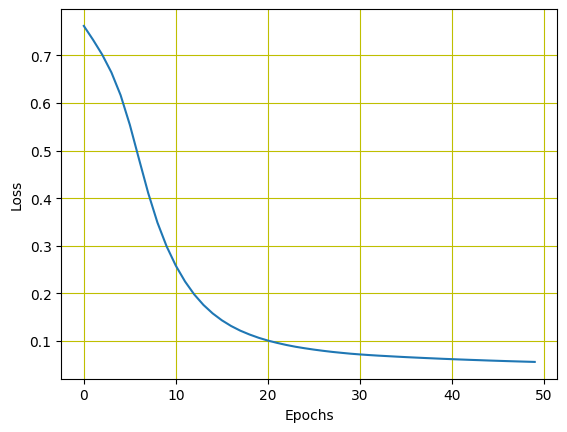

In [29]:
plt.plot(loss_arr)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid('True', color = 'y')
plt.show()

In [30]:
model.eval()

y_pred = model(X_test)

acc = (y_pred.round() == Y_test).float().mean()

print(f"Accuracy: {acc}")

Accuracy: 0.9528301954269409


<h2>Exponential scheduling</h2>
In which the learning rate is updated by multiplying with a constant factor gamma in each scheduler update.





In [32]:
#create model
model2 = nn.Sequential(
    nn.Linear(34, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid()
)

In [33]:
n_epochs = 50
lr = 0.1
loss_fn = nn.BCELoss()
optimizer = optim.SGD(model2.parameters(),  lr = lr)
batch_size = 15
loss_arr = []
#lr schedulder
scheduler = lr_scheduler.ExponentialLR(optimizer, gamma = 0.99)

for epoch in range(n_epochs):
  batch_loss = 0
  for i in range(0, len(X_train), batch_size):
    X_batch = X_train[i:i+batch_size]
    Y_batch = Y_train[i:i+batch_size]

    #forward pass
    Y_pred = model2(X_batch)

    #get the loss
    loss = loss_fn(Y_pred, Y_batch)

    #now calculate gradients
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    batch_loss += loss.item()

  #epoch end
  loss_arr.append(batch_loss/batch_size)
  before_lr = optimizer.param_groups[0]["lr"]
  scheduler.step()
  after_lr = optimizer.param_groups[0]["lr"]
  print(f"Epoch: {epoch + 1} Loss: {batch_loss/batch_size} {before_lr} => {after_lr}")








Epoch: 1 Loss: 0.7686265309651693 0.1 => 0.099
Epoch: 2 Loss: 0.7321922302246093 0.099 => 0.09801
Epoch: 3 Loss: 0.6985389073689778 0.09801 => 0.0970299
Epoch: 4 Loss: 0.6559637367725373 0.0970299 => 0.096059601
Epoch: 5 Loss: 0.6017525871594747 0.096059601 => 0.09509900499
Epoch: 6 Loss: 0.5351598123709361 0.09509900499 => 0.0941480149401
Epoch: 7 Loss: 0.4611222465833028 0.0941480149401 => 0.093206534790699
Epoch: 8 Loss: 0.38942549427350365 0.093206534790699 => 0.09227446944279201
Epoch: 9 Loss: 0.3276369571685791 0.09227446944279201 => 0.09135172474836409
Epoch: 10 Loss: 0.2767190853754679 0.09135172474836409 => 0.09043820750088044
Epoch: 11 Loss: 0.23522064487139385 0.09043820750088044 => 0.08953382542587164
Epoch: 12 Loss: 0.20160064448912937 0.08953382542587164 => 0.08863848717161292
Epoch: 13 Loss: 0.17440205464760464 0.08863848717161292 => 0.08775210229989679
Epoch: 14 Loss: 0.15265724410613377 0.08775210229989679 => 0.08687458127689782
Epoch: 15 Loss: 0.1345811093846957 0.086

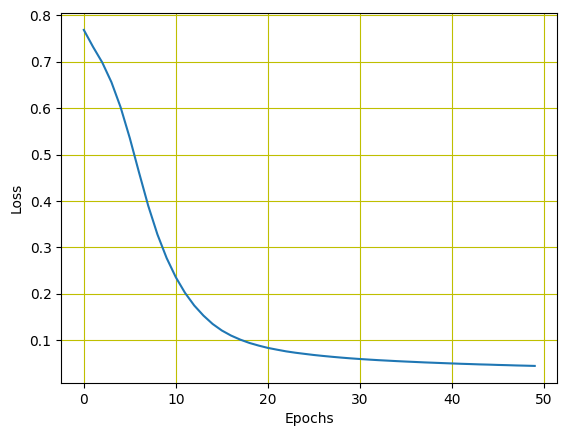

In [34]:
plt.plot(loss_arr)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid('True', color = 'y')
plt.show()

In [35]:
model.eval()

y_pred = model2(X_test)

acc = (y_pred.round() == Y_test).float().mean()

print(f"Accuracy: {acc}")

Accuracy: 0.9433962106704712
